Author: Robin Sternberg  
This notebook is licensed under Creative Commons Attribution-ShareAlike 4.0

# Statistische Analyse 2 - Wörter in den Zwischenrufen

In diesem Notebook wird beleuchtet, was denn eigentlich so in den Zwischenrufen gesagt wird, und wie sich die Zwischenrufe der Parteien ähneln.

## Initialisierung und Daten laden

In [13]:
import pandas as pd
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import seaborn as sns
pd.set_option('chained_assignment',None)
nltk.download('punkt') # if not downloaded yet

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Robin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'BSW', 'fraktionslos']

df_interruptions = pd.read_csv('../_data/interruptions.csv')
df_interruptions.head(10)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der Welt!,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
3,3,Gebt erst mal das Vermögen der DIE LINKE dem S...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
4,4,Die DIE LINKE soll das Vermögen zurückgeben!,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
5,5,Wundert Sie das?,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
6,6,Der muß auch noch reden? Reicht denn nicht einer?,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
7,7,Das sagen Sie!,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
8,8,Wohl wahr!,FDP,Dr. Graf Lambsdorff,FDP,Dr. Wolfgang Weng,1991-03-12,180,8
9,9,Haben Sie vergessen hinzuschauen?,SPD,<unknown>,FDP,Dr. Wolfgang Weng,1991-03-12,180,8


Einige (wenige) Felder sind leider leer aus den Protokollen geparst worden. Die nehmen wir jetzt heraus.

In [9]:
non_string_entries = df_interruptions['comment_text'].apply(lambda x: not isinstance(x, str))
df_interruptions[non_string_entries]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
12390,12390,NaN,CDU/CSU,<unknown>,SPD,Jan Oostergetelo,1992-06-24,75,8688
16448,16448,NaN,CDU/CSU,Bartholomäus Kalb,CDU/CSU,Manfred Kolbe,1992-11-26,87,11505
46789,46789,NaN,FDP,Dr. Klaus Röhl,SPD,Ursula Burchardt,1996-04-24,38,35146
84860,84860,NaN,CDU/CSU,Norbert Geis,SPD,Hermann Bachmaier,2000-03-23,33,58284
84963,84963,NaN,SPD,Ludwig Stiegler,CDU/CSU,Dr. Norbert Lammert,2000-03-24,58,58310
87891,87891,NaN,FDP,Hans-Michael Goldmann,FDP,Marita Sehn,2000-06-29,33,59727
336957,336957,NaN,FDP,Benjamin Strasser,SPD,Dr. Lars Castellucci,2017-12-13,50,168580
391885,391885,NaN,AfD,Marc Bernhard,AfD,Marc Bernhard,2020-11-26,34,195920
413825,413825,NaN,AfD,Jörn König,AfD,Jörn König,2022-06-23,39,208703
418548,418548,NaN,DIE LINKE,Dr. Petra Sitte,SPD,Simona Koß,2022-09-23,37,210260


In [10]:
df_interruptions= df_interruptions[~non_string_entries]

## Inhalte der Zwischenrufe nach Parteien

Hier werden zwei Listen zusammengestellt. Die erste enthält den gesamten Inhalt der Zwischenrufe nach Partei jeweils in einem langen String. 

In [11]:
texts_per_party = df_interruptions.groupby('comment_party')['comment_text'].apply(lambda x: ' '.join(x))

Die zweite Liste enhält für jede Partei eine Liste an Zwischenrufen, aber mit eigenen Listeneinträgen pro Zwischenruf. Das ist für die TFIDF-Vektorisierung später notwendig.

In [19]:
texts_per_party_lists = []
df_interruptions.groupby('comment_party')['comment_text'].apply(lambda x: texts_per_party_lists.append(x.to_list()))
for l in texts_per_party_lists:
    print (len(l))

31416
137225
40827
71700
75481
120957
83


In [40]:
texts_per_party

comment_party
AfD             Ha, ha, ha! Das ist nicht unser Problem! Ui, d...
CDU/CSU         Gebt erst mal das Vermögen der DIE LINKE dem S...
DIE LINKE       So kriegen Sie die Steuerlüge nicht aus der We...
FDP             Wohl wahr! Verfassungswidrig! Unfug! Wofür sol...
GRÜNE           Das ist Rea -lität! Sie fielen gestern im Plen...
SPD             Bravo! Haben Sie vergessen hinzuschauen? Sind ...
fraktionslos    Bei Wechsel der Verhältnisse! Er ist trotz dem...
Name: comment_text, dtype: object

Auch in dieser Analyse machen uns die Protokollfehler wieder zu schaffen...  
Teilweise sind Kommentare nicht richtig abgeschlossen. Entweder das Protokoll springt mitten im Satz, die ')' fehlt, oder bei Abschluss eines Zwischenrufs mit '-' fehlt das Leerzeichen. Nach dem '-'. Dann ist es mit RegEx nicht mehr von Wörtern mit Binde-Strich zu unterscheiden.
Am Beispiel der CDU/CSU hier: 

In [36]:
errlist = []
for comment in texts_per_party_lists[1]:
    if '[CDU/CSU' in comment:
        errlist.append(comment)

print(len(errlist))
for err in errlist[20:30]: 
    print(err)

242
Der Wald ist (Heinrich-Wilhelm Ronsöhr [CDU/CSU]: Daschon auf die Regierung sauer!
Die können Hartmut Schauerte [CDU/CSU]: Ich will ja gar eben nicht mit Geld umgehen!
Was spricht denn dagegen? Die Menschen wollen aber ihre Partnerschaft begründen und ihr Leben gestalten, und das findet nicht nur an diesen Orten statt, auch wenn das offensichtlich noch Ihrem etwas zurückgebliebenen Bild von dieser sozialen Gruppe entspricht. Wir packen die notwendigen Reformen auch in anderen Bereichen an und werden sie in diesem Jahr auf den Weg bringen bzw. durchsetzen: zum Beispiel die Reform des Mietrechts und des strafrechtlichen Sanktionensystems. Das Gesetz zur Ächtung der Gewalt in der Erziehung, das wir hier beschlossen haben, setzt ein wichtiges Zeichen, und ich hoffe, dass Sie das im Bundesrat mitmachen. Wir müssen ein Signal gegen die Gewalt in der Gesellschaft setzen. Wir wollen festhalten, dass Kinder ein Recht auf eine gewaltfreie Erziehung haben. (Norbert Geis [CDU/CSU]: Aus diesem 

Zum Glück unterliegt der Großteil unserer Daten diesen Fehlern nicht.

In [39]:
print(len(errlist)/len(texts_per_party_lists[1]))

0.0017635270541082164


# N-Gramme nach Partei

Im nächsten Abschnitt werden die N-Gramme nach Partei extrahiert und ausgegeben.

In [15]:
def get_ngrams(text, n):
    tokens = word_tokenize(text, language = 'german')
    return list(ngrams(tokens, n))

ngrams_data = {}
for party, text in texts_per_party.items():
    print(party)
    unigrams = get_ngrams(text, 1)
    bigrams = get_ngrams(text, 2)
    trigrams = get_ngrams(text, 3)
    
    ngrams_data[party] = {
        'unigrams': Counter(unigrams),
        'bigrams': Counter(bigrams),
        'trigrams': Counter(trigrams)
    }

AfD
CDU/CSU
DIE LINKE
FDP
GRÜNE
SPD
fraktionslos


In [17]:

for party, ngram_counts in ngrams_data.items():
    print(f"Partei: {party}")
    print(f"Häufigste unigramme:{ ngram_counts['unigrams'].most_common(10)}")
    print(f"Häufigste bigramme: {ngram_counts['bigrams'].most_common(10)}")
    print(f"Häufigste trigramme: {ngram_counts['trigrams'].most_common(10)}")
    print()

Partei: AfD
Häufigste unigramme:[(('!',), 35186), (('Sie',), 8768), ((',',), 7053), (('Das',), 5728), (('?',), 4878), (('ist',), 4731), (('nicht',), 4119), (('die',), 3651), (('das',), 3058), (('doch',), 2888)]
Häufigste bigramme: [(('!', 'Das'), 5068), (('Das', 'ist'), 2362), (('!', 'Sie'), 2319), (('!', 'Die'), 1354), (('nicht', '!'), 1237), (('!', 'Ja'), 1065), (('!', 'Was'), 872), (('Ja', ','), 816), (('!', 'Wir'), 760), ((',', 'Herr'), 751)]
Häufigste trigramme: [(('!', 'Das', 'ist'), 2083), (('!', 'Ja', ','), 729), (('!', 'Sie', 'haben'), 532), (('!', 'Hört', '!'), 443), (('Das', 'ist', 'doch'), 415), (('!', 'Genau', '!'), 382), (('!', 'Ja', '!'), 320), (('!', 'Sie', 'sind'), 292), (('?', 'Das', 'ist'), 266), (('!', 'Das', 'war'), 259)]

Partei: CDU/CSU
Häufigste unigramme:[(('!',), 142508), (('Sie',), 28714), (('Das',), 27296), ((',',), 26995), (('ist',), 25718), (('nicht',), 18902), (('?',), 18791), (('die',), 14584), (('das',), 13026), (('doch',), 12509)]
Häufigste bigramme: [

Aus diesen N-Grammen lässt sich noch nicht sonderlich viel ablesen. Eigentlich kann man sagen, die N-Gramme sind unter den großen Parteien fast identisch. Nur bei den fraktionslosen abgeordneten ändert sich das. Aber auch nur, weil hier die Anzahl nicht im Tausender-Bereich, sondern einstellig ist.

Um aussagekräftigere Analysen zu erhalten, müssen wir also Stopwords definieren.  

\*Anmerkung: Anscheinend ist das '!' sehr hoch im Kurs. Wie viel Prozent der Unterbrechungen enthalten denn ein Ausrufezeichen? 

In [18]:
percentage_excl_marks = df_interruptions['comment_text'].apply(lambda x:'!' in x).sum()/len(df_interruptions)*100
print(f"{percentage_excl_marks:.2f} %")

88.37 %


Die Kommentatoren wollen sich anscheinend Ausdruck verleihen. Sonst würden sie ja niemanden unterbrechen...

## Stopwords

Die Liste an Stopwords habe ich von [hier](https://github.com/stopwords-iso/stopwords-de/blob/master/raw/stop-words-german.txt) heruntergeladen und dann angepasst.
Beispielsweise habe ich 'ja' und 'nein' wieder aus der Liste entfernt, da diese Wörter bei Zwischenrufen wichtig sind.

In [88]:
file_path = '../_data/stop_words_german.txt'

# read the stopwords from the file into a list
with open(file_path, 'r', encoding='utf-8') as file:
    stop_words = [line.strip() for line in file if line.strip()]

stop_words.extend(['herr', 'frau','mal', 'reden', '!', '.', '"', ',', '„','“', '?', '[', ']', 'sagen', 'CDU', 'CSU' 'Beifall', '/', 'Abgeordneten','(', ')', ':', '\x96'])
stop_words.extend(parties) # we don't care about party mentions. CDU and CSU appended before because only 'CDU/CSU' in list 'parties'

print (stop_words)

['a', 'ab', 'aber', 'ach', 'acht', 'achte', 'achten', 'achter', 'achtes', 'ag', 'alle', 'allein', 'allem', 'allen', 'aller', 'allerdings', 'alles', 'allgemeinen', 'als', 'also', 'am', 'an', 'andere', 'anderen', 'andern', 'anders', 'au', 'auch', 'auf', 'aus', 'ausser', 'außer', 'ausserdem', 'außerdem', 'b', 'bald', 'bei', 'beide', 'beiden', 'beim', 'beispiel', 'bekannt', 'bereits', 'besonders', 'besser', 'besten', 'bin', 'bis', 'bisher', 'bist', 'c', 'd', 'da', 'dabei', 'dadurch', 'dafür', 'dagegen', 'daher', 'dahin', 'dahinter', 'damals', 'damit', 'danach', 'daneben', 'dank', 'dann', 'daran', 'darauf', 'daraus', 'darf', 'darfst', 'darin', 'darüber', 'darum', 'darunter', 'das', 'dasein', 'daselbst', 'dass', 'daß', 'dasselbe', 'davon', 'davor', 'dazu', 'dazwischen', 'dein', 'deine', 'deinem', 'deiner', 'dem', 'dementsprechend', 'demgegenüber', 'demgemäss', 'demgemäß', 'demselben', 'demzufolge', 'den', 'denen', 'denn', 'denselben', 'der', 'deren', 'derjenige', 'derjenigen', 'dermassen', '

In [52]:
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter

def get_ngrams(text, n, stop_words):
    tokens = [word for word in word_tokenize(text, language='german') if word.lower() not in stop_words]
    return list(ngrams(tokens, n))

ngrams_data = {}
stop_words = set(stop_words)  # Convert the stop_words list to a set for faster look-up

for party, text in texts_per_party.items():
    print(party)
    unigrams = get_ngrams(text, 1, stop_words)
    bigrams = get_ngrams(text, 2, stop_words)
    trigrams = get_ngrams(text, 3, stop_words)
    
    ngrams_data[party] = {
        'unigrams': Counter(unigrams),
        'bigrams': Counter(bigrams),
        'trigrams': Counter(trigrams)
    }


AfD
CDU/CSU
DIE LINKE
FDP
GRÜNE
SPD
fraktionslos


In [53]:

for party, ngram_counts in ngrams_data.items():
    print(f"Partei: {party}")
    print(f"Häufigste unigramme:{ ngram_counts['unigrams'].most_common(10)}")
    print(f"Häufigste bigramme: {ngram_counts['bigrams'].most_common(10)}")
    print(f"Häufigste trigramme: {ngram_counts['trigrams'].most_common(10)}")
    print()

Partei: AfD
Häufigste unigramme:[(('ja',), 1477), (('Ja',), 1207), (('Genau',), 603), (('Hört',), 483), (('Nein',), 470), (('sagen',), 363), (('wissen',), 323), (('Quatsch',), 307), (('Thema',), 273), (('Unsinn',), 273)]
Häufigste bigramme: [(('Hört', 'Hört'), 245), (('Ja', 'ja'), 104), (('Hass', 'Hetze'), 81), (('Ja', 'genau'), 72), (('Fake', 'News'), 50), (('Gottes', 'willen'), 39), (('Oh', 'ja'), 34), (('kennen', 'ja'), 31), (('ja', 'ja'), 29), (('Ja', 'Ja'), 28)]
Häufigste trigramme: [(('Hört', 'Hört', 'Hört'), 18), (('Bla', 'bla', 'bla'), 14), (('ja', 'Hört', 'Hört'), 8), (('Ja', 'Hört', 'Hört'), 8), (('deutschen', 'demokratischen', 'Altfraktionen'), 8), (('Hört', 'Hört', 'Genau'), 7), (('Oh', 'oh', 'oh'), 7), (('Aha', 'Hört', 'Hört'), 6), (('ja', 'Hass', 'Hetze'), 6), (('Deutsche', 'demokratische', 'Altfraktionen'), 6)]

Partei: CDU/CSU
Häufigste unigramme:[(('ja',), 5287), (('Ja',), 3237), (('Hört',), 2559), (('Genau',), 2373), (('wahr',), 2146), (('stimmt',), 2069), (('Nein',),

### Auffälligkeiten:

1. In allen Parteien (außer bei den fraktionslosen Abgeordneten) sind die Wörter "ja", "Ja", "Genau" und "Nein" häufig vertreten. Daraus kann man schließen, dass viele Zwischenrufe entweder zustimmend, oder ablehnend sind. 
2. Bei der AfD tauchen spezifische Begriffe, wie "Hass" und "Hetze" auf. Das zeigt die oppositionelle Stellung der AfD, aus der heraus die AfD den anderen Parteien viele Vorwürfe macht.
3. Bei den Linken ist "Antrag" häufiger zu finden, als bei allen anderen Parteien.
4. Abfällige Begriffe, wie "Quatsch" und "Unsinn" sind besonders bei AfD und Linke zu finden. Das deutet einen raueren Ton bei den Zwischenrufen dieser Parteien an.

\*Anmerkung: Bei den fraktionslosen Abgeordneten ist die Datenlage relativ eng, weshalb die N-Gramme kaum Aussagekraft haben.

# Wordclouds zu Wörtern aus den Zwischenrufen

Da die N-Gramm-Darstellung nicht sonderlich visuell ansprechend war, sind hier noch mit der gleichen Liste an Stopwörtern ein paar Wordclouds geplottet.  
Da sich sehr viel überschneidet, habe ich nicht für jede Partei einen eigenen Plot gemacht.

Dabei habe ich die CDU/CSU als Repräsentanten für die Volksparteien gewählt.

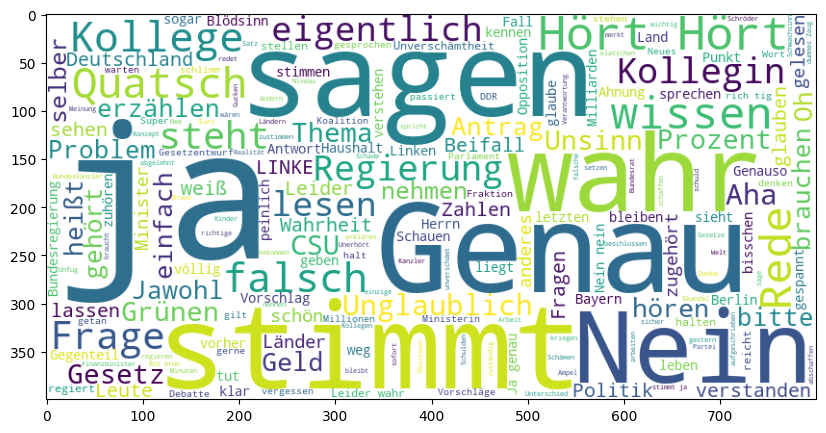

In [83]:
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(texts_per_party['CDU/CSU'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Die AfD habe ich gewählt, da sie bisher nur in der Opposition war und im vorigen Notebook besonders durch viele Zwischenrufe aufgefallen ist.

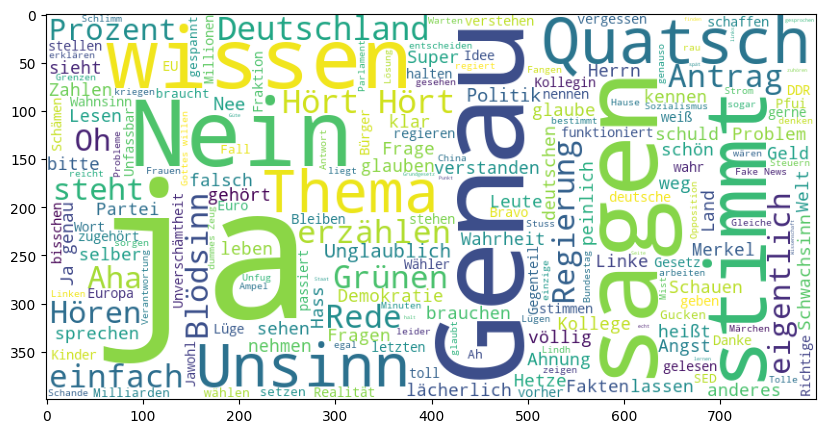

In [86]:
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(texts_per_party['AfD'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

# Lexical Diversity

Neben den Wörtern, die gesagt wurden, ist auch interessant, wie unterschiedlich die Zwischenrufe sind.  
Dafür kann man die Lexical Diversity berechnen. Diese ist einfach der Quotient aus einzigartigen Tokens durch die Länge der Texte in Tokens.

In [91]:
def lexical_diversity(text):
    tokens = word_tokenize(text, language='german')
    unique_tokens = set(tokens)
    return len(unique_tokens) / len(tokens)


lexical_diversities = {}
for party, text in texts_per_party.items():
    diversity = lexical_diversity(text)
    lexical_diversities[party] = diversity


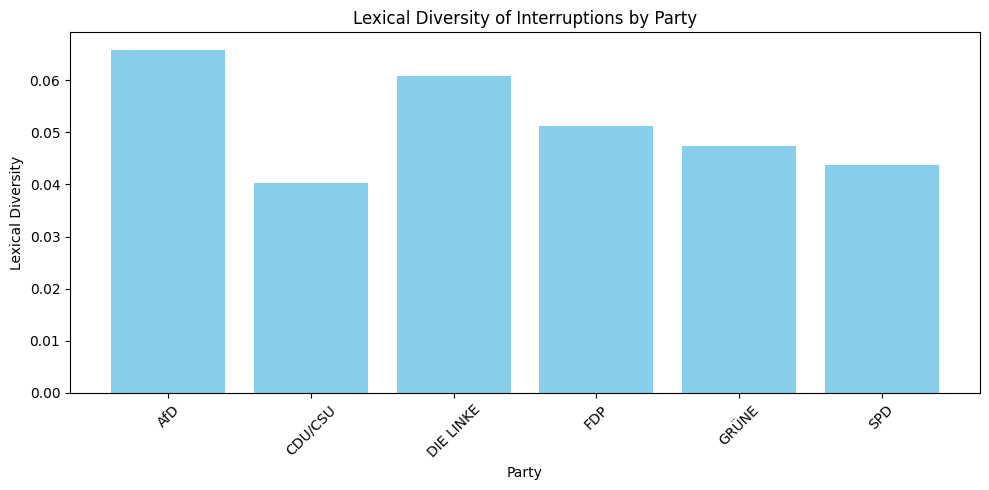

In [22]:

lexical_diversities.pop('fraktionslos')  # without fraktionslos as we don't have enough data samples
plt.figure(figsize=(10, 5))
plt.bar(lexical_diversities.keys(), lexical_diversities.values(), color='skyblue')
plt.xlabel('Party')
plt.ylabel('Lexical Diversity')
plt.title('Lexical Diversity of Interruptions by Party')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Die AfD scheint wohl am kreativsten mit ihren Zwischenrufen zu sein, während die CDU/CSU eher in alte Muster zurückfallen und öfter das Gleiche sagen, als die anderen Parteien. 

# TFIDF 

Im folgenden Abschnitt werden TFIDF-Vektoren über die Zwischenrufe berechnet.

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as  np

In diesem Block zuerst die TFIDF-Vektoren nach Partei, bei denen der Vectorizer auch jeweils nur auf den "Dokumenten" (Zwischenrufen) der jeweiligen Partei gefittet wird.  
Danach werden die top 10 Wörter pro Partei ausgegeben. Auch hier benutzten wir wieder Stoppwörter.   
Mit min und max_df habe ich etwas herumgespielt, bis aussagekräftige Ergebnisse herausgekommen sind.  

In [95]:
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, min_df=3, max_df=0.6)
tfidf_vecs_parties =[]
features_names_parties = []

for party_texts in texts_per_party_lists:
    tfidf_vec = vectorizer.fit_transform(party_texts) #
    feature_names = vectorizer.get_feature_names_out()
    tfidf_vecs_parties.append(tfidf_vec)
    features_names_parties.append(feature_names)

for i, (party_tfidf, party_feature_names) in enumerate(zip(tfidf_vecs_parties, features_names_parties)):
    party_tfidf_array = party_tfidf.toarray()
    
    # sum the tfidf values for each word across all documents for the party
    sum_tfidf_values = party_tfidf_array.sum(axis=0)

    top_indices = np.argsort(sum_tfidf_values)[::-1][:10]
    top_words = party_feature_names[top_indices]
    
    # rint the top 10 words for this party
    print(f"Top Wörter für {parties[i]}: {top_words}")

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abgeordneten', 'afd', 'cdu', 'csu', 'csubeifall', 'ernst', 'fdp', 'grüne', 'linke', 'ordnung', 'schluss', 'spd', 'wahr'] not in stop_words.
  warnings.warn(


Top Wörter für CDU/CSU: ['ja' 'genau' 'nein' 'stimmt' 'hört' 'quatsch' 'wissen' 'unsinn' 'thema'
 'aha']
Top Wörter für SPD: ['ja' 'genau' 'stimmt' 'wahr' 'nein' 'hört' 'quatsch' 'falsch' 'aha' 'spd']
Top Wörter für GRÜNE: ['ja' 'genau' 'stimmt' 'nein' 'quatsch' 'hört' 'unglaublich' 'frage'
 'wahr' 'oh']
Top Wörter für FDP: ['ja' 'stimmt' 'nein' 'genau' 'wahr' 'quatsch' 'aha' 'spd' 'leider' 'hört']
Top Wörter für AfD: ['ja' 'genau' 'stimmt' 'nein' 'quatsch' 'wissen' 'frage' 'steht' 'hört'
 'antrag']
Top Wörter für DIE LINKE: ['ja' 'genau' 'stimmt' 'wahr' 'nein' 'quatsch' 'hört' 'wissen' 'falsch'
 'fdp']
Top Wörter für fraktionslos: ['wahr' 'ja' 'danke' 'unglaublich' 'frage']


Was hier auffällt ist, dass die Top 10 Wörter nach TFIDF-Häufigkeit sich stark den Wörtern ähneln, die bei den absoluten Zählen der N-Grammer herausgekommen sind. 

# Ähnlichkeiten zwischen den Parteien

Um mittels TFIDF-Vektoren die Kosinus-Ähnlichkeit zwischen den Parteien zu berechnen, muss der Vectorizer auf allen Zwischenrufen gefittet werden.

In [96]:
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, min_df=3, max_df=0.6)

tfidf_vecs_parties =[]
features_names_parties = []
all_comment_texts =[]
for sublist in texts_per_party_lists:
    all_comment_texts.extend(sublist)

vectorizer.fit(all_comment_texts)
feature_names=vectorizer.get_feature_names_out()
for party_texts in texts_per_party_lists:
    tfidf_vec = vectorizer.transform(party_texts)
    tfidf_vecs_parties.append(tfidf_vec)
    

In [102]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

average_tfidf_vectors_sparse = [csr_matrix.mean(tfidf_vec, axis=0) for tfidf_vec in tfidf_vecs_parties]

# stack the sparse average vectors into a single sparse matrix
average_tfidf_matrix = csr_matrix(np.vstack(average_tfidf_vectors_sparse)) # compressed sparse row matrix so that my RAM can handle it

cosine_sim_matrix_sparse = cosine_similarity(average_tfidf_matrix)

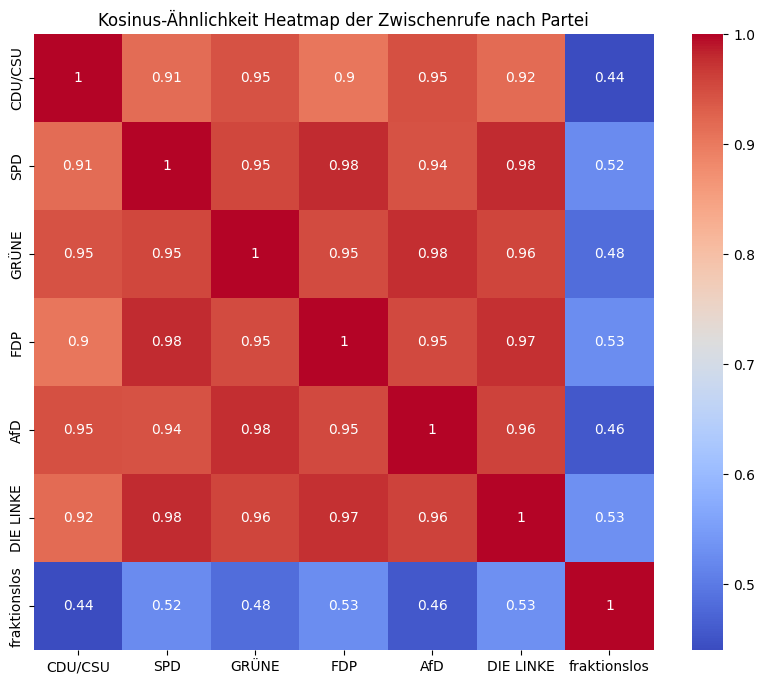

In [103]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_matrix_sparse, xticklabels=parties, yticklabels=parties, cmap='coolwarm', annot=True)
plt.title('Kosinus-Ähnlichkeit Heatmap der Zwischenrufe nach Partei')
plt.show()

In [104]:
cosine_sim_matrix_sparse = cosine_sim_matrix_sparse[:-1,:-1] # delete fraktionslos as they break patterns due to not enough data

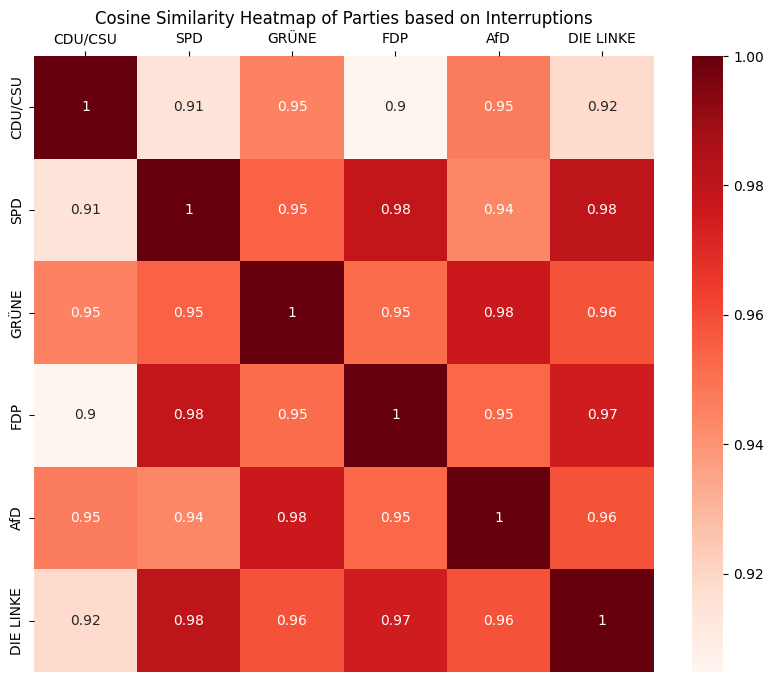

In [105]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cosine_sim_matrix_sparse, xticklabels=parties[:-1], yticklabels=parties[:-1], cmap='Reds', annot=True) #different colormap

ax.xaxis.set_label_position('top')
ax.xaxis.set_ticks_position('top')
plt.title('Cosine Similarity Heatmap of Parties based on Interruptions')
plt.show()

Was hier direkt in mein Auge gesprungen ist, ist, dass die Zwischenrufe der Grünen denen der AfD wohl am ähnlichsten sind.  
Das könnte auf die disruptive Vergangenheit der Grünen zurückzuführen sein, in der sie in der Opposition der 18. Bundestagsperiode die meisten Zwischenrufe verursacht hat.


Diese Scores müssen aber mit Vorsicht interpretiert werden. Einfaches Mitteln der TFIDF-Vektoren und anschließendes Berechnen der Kosinus-Ähnlichkeit ist lediglich ein Indiz und kein absoluter Beweis für die Ähnlichkeit zweier Texte (oder zweier Listen von Zwischenrufen).

# Abschnitt "Interessante Zwischenrufe"

Im Rahmen der Analysen sind mir mehrere interessante Zwischenrufe aufgefallen. Die habe ich hier an einer Stelle gesammelt.

In [106]:
pd.set_option('display.max_colwidth', None)

### "Hört Hört"

Die Wortfolge Hört Hört ist wohl ziemlich beliebt...

In [107]:
df_hoert_hoert = df_interruptions[df_interruptions['comment_text'].apply(lambda x: bool(re.search('hört.* hört.*', x, flags= re.UNICODE|re.IGNORECASE)))]
print(len(df_hoert_hoert))
df_hoert_hoert.head(5)

3426


,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
324,324,Hört! Hört!,SPD,<unknown>,SPD,Ingrid Matthäus-Maier,1991-04-17,48,703
391,391,Hört! Hört!,CDU/CSU,Arnulf Kriedner,CDU/CSU,Dr. Gero Pfennig,1991-04-17,36,715
425,425,Hört! Hört!,FDP,<unknown>,CDU/CSU,Dr. Angela Merkel,1991-04-18,81,739
470,470,Hört! Hört! Da wer-den wir aufpassen!,SPD,Dr. Uwe Küster,CDU/CSU,Susanne Rahardt-Vahldieck,1991-04-18,65,754
510,510,Hört! Hört!,CDU/CSU,Peter Kittelmann,CDU/CSU,Horst Eylmann,1991-04-18,45,799


### "Verschwörungstheoretiker"

"Verschwörungstheoretiker" kommt zuerst 2016 vor, ist aber seitdem bis 2022 fast regelmäßig in Zwischenrufen aufgetaucht.

In [64]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Verschwörungstheoretiker', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
319479,319479,Alles Verschwörungstheoretiker!,GRÜNE,Sylvia Kotting-Uhl,SPD,Klaus Barthel,2016-05-11,77,159802
344437,344437,Von anderen Verschwörungstheoretikern!,FDP,Konstantin Kuhle,AfD,Stephan Brandner,2018-06-14,50,172765
353769,353769,Verschwörungstheoretiker!,SPD,<unknown>,AfD,Armin-Paulus Hampel,2018-11-30,51,176937
354750,354750,Die Krise ist ja nicht weg! Verschwörungstheoretiker!,AfD,Leif-Erik Holm,SPD,Metin Hakverdi,2018-12-13,61,177358
361267,361267,Verschwörungstheoretiker!,AfD,Jörg Schneider,FDP,Konstantin Kuhle,2019-04-05,17,180649
381414,381414,Verschwörungstheoretiker!,AfD,Stephan Brandner,CDU/CSU,Philipp Amthor,2020-05-07,91,190042
381466,381466,So ein Quatsch! Verschwörungstheoretiker! Setzen Sie sich lieber Ihren Aluhut auf!,CDU/CSU,Tino Sorge,AfD,Detlev Spangenberg,2020-05-07,70,190059
383557,383557,Sie laufen ja lieber bei Verschwörungstheoretikern mit!,SPD,Timon Gremmels,AfD,Andreas Bleck,2020-05-29,44,191167
385491,385491,"Uns als Verschwörungstheoretiker zu bezeichnen, wenn man sagt, dass die Staaten mehr Geld zahlen sollen, ist unerhört!",DIE LINKE,Evrim Sommer,FDP,Ulrich Lechte,2020-07-03,42,192327
400261,400261,Das sagen alle Verschwörungstheoretiker!,AfD,Elsner von Gronow,SPD,Dr. Karl-Heinz Brunner,2021-05-07,40,201478


### Metakommentare:

Zwischenrufe über Zwischenrufe selbst

In [65]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Zwischenruf.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
395,395,Aber Zwischenrufe sind erlaubt!,CDU/CSU,Gerhard Reddemann,SPD,Dr. Wilfried Penner,1991-04-18,8,717
1425,1425,"„Uns ken nen alle"" war der Zwischenruf des Kollegen Weng!",CDU/CSU,Bartholomäus Kalb,CDU/CSU,Irmgard Karwatzki,1991-06-04,58,1380
1595,1595,Der Zwischenruf des Jahres!,SPD,fried Penner,FDP,Ina Albowitz,1991-06-05,133,1453
3689,3689,Zwischenrufe nie!,SPD,Gerd Andres,CDU/CSU,Arnulf Kriedner,1991-09-05,76,2669
4086,4086,"Das war keine Frage, das war nur ein Zwischenruf!",SPD,Peter Conradi,SPD,Dorle Marx,1991-09-19,7,2909
...,...,...,...,...,...,...,...,...,...
456133,456133,Zwischenrufe sind zulässig!,AfD,Enrico Komning,GRÜNE,Dr. Till Steffen,2023-11-09,38,222775
462514,462514,"Das zeigt mal wieder, wo Sie hängen geblieben sind, in welchem Zeitalter, was Sie dazwischenrufen!",GRÜNE,Tobias B. Bacherle,AfD,Dr. Gottfried Curio,2023-12-15,61,224593
464987,464987,"Das ist so unterkomplex, da kann man nicht in Zwischenrufen alles aufzählen, was da fehlt!",SPD,Dr. Wiebke Esdar,CDU/CSU,Thomas Jarzombek,2024-01-30,60,225259
468335,468335,Da wäre der Zwischenruf „Fake News“ noch ein Euphemismus!,SPD,Sebastian Hartmann,CDU/CSU,Andrea Lindholz,2024-03-14,86,226377


Das hier ist mein Favorit aus der Rubrik Metakommentare

In [67]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Da fallen einem schon.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
399085,399085,"Da fallen einem schon keine Zwischenrufe mehr ein, so absurd ist das!",FDP,Graf Lambsdorff,DIE LINKE,Heike Hänsel,2021-04-22,40,200654


### Internetseiten

Hin und wieder sind auch Internetseiten Teil der Debatte. Mein Favorit "www.ichglaubejedenscheiss.de"

In [108]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*\.de.*|.*\.com.*|www\..*', str(x), flags= re.UNICODE|re.IGNORECASE)))][1:] # first one is a protocol error

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
332180,332180,Ich empfehle www.linksfraktion.de !,DIE LINKE,Matthias W. Birkwald,SPD,Mechthild Rawert,2017-03-31,57,166188
468863,468863,www.ichglaubejedenscheiss.de!,AfD,Martin Reichardt,SPD,Josephine Ortleb,2024-03-15,34,226513
469442,469442,chefkoch.de!,AfD,Beatrix von Storch,SPD,Dr. Jens Zimmermann,2024-03-21,51,226793
469466,469466,chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,226800
469467,469467,Für chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,226800
469468,469468,chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,226800


### Sonstige Zwischenrufe

In [ ]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Naturschutzzerstörungsfraktion', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
400588,400588,Die Naturschutzzerstörungsfraktion seid ihr!,AfD,Karsten Hilse,GRÜNE,Steffi Lemke,2021-05-20,37,201649


In [109]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Das ist viel zu billig.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
157599,157599,Das ist viel zu billig! So billig sind Sie doch gar nicht! Entlassen Sie den Redenschreiber! Das alles ist viel zu billig!,CDU/CSU,Michael Glos,SPD,Gerhard Schröder,2004-11-24,354,84046


In [110]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Die Sendung mit der Maus.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
376997,376997,„Die Sendung mit der Maus“!,CDU/CSU,Dr. Georg Nüßlein,DIE LINKE,Gösta Beutin,2020-01-17,62,187610
429177,429177,"Ja, das ist genau Ihr intellektuelles Niveau: „Die Sendung mit der Maus“!",AfD,Martin Reichardt,DIE LINKE,Heidi Reichinnek,2022-12-15,34,213532


... Deutsches Kulturgut.

# Fazit

Die statistische Analyse der Wörter war nicht ganz so aussagekräftig, wie die Analysen im vorigen Notebook.  
Trotzdem haben sich z.B. bei den N-Grammen ein paar Muster innerhalb der Parteien herauskristallisiert und Unterschiede in der Wortwahl und im Stil der Zwischenrufe gezeigt. 